# Tovesson $^{239}$Pu(n,f)/$^{235}$U(n,f) cs shape data preparation for GMA (Data release: LA-UR-25-32229)

In [1]:
import os
from importlib import reload
from numpy import array, shape, ones, zeros, loadtxt, interp,arange,sqrt
from matplotlib.pyplot import figure, show, plot, xlabel, ylabel, legend, semilogx
%matplotlib inline

In [3]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [7]:
import Class_nfcs_legacy as Cnf

In [9]:
# Data in here are all taken from EXFOR.
datafile = homedir+'DS8002.dat'
alldata  = loadtxt(datafile,skiprows=2)
Einc = alldata[:,0]*1.0e-6
Data = alldata[:,1]
statunc = alldata[:,2] # The statistical unc.
# is explicitly given in EXFOR.

backgrdU5 = alldata[:,3] # The U-235 background
# reduction uncertainty is explicitly given in 
# EXFOR. I assume it to be Gaussian correlated.

backgrdPu9 = alldata[:,4] # The Pu-239 background
# reduction uncertainty is explicitly given in 
# EXFOR. I assume it to be Gaussian correlated.

normalization = 2.0 # %
# The normalization uncertainty was defined by comparison to the thermal cross
# section ratio and therefore completely different than from any other
# measurement. It was not included in the GMA uncertainty estimate.
# It is fully correlated.


In [11]:
# All uncertainties in here are taken from the literature related to the measurement.

dim = shape(Einc)[0]

# All data points in that measurement are from the WNR measurement and therefore, only
# time resolution and TOF length uncertainties apply for this part of the measurement.
# The uncertainty is given in the Pu-9 paper.
TOFlength = 10.882 # m
TOFlenght_unc = 0.002 # m
trsl = 1.6 # ns

# The uncertainty on the residual detector efficiency uncertainty is given in the 
# Np-237 paper and accounts for different thresholds for Pu-9 and U-235. I assume
# a full correlation.
detectorunc = 0.5*ones(dim,dtype=float)  #%

# The deadtime uncertainty is given in the Np-237 paper. I assume a full correlation
# following the template.
deadtime  = 0.1*ones(dim,dtype=float) #%



In [13]:
# All uncertainties are assumed.


# Impurity unc. ---------------------------------------------------------
impurity = ones(dim,dtype=float)*0.1 # % 
# No impurity uncertainty is given. I assume the value provided by Kyle Schmitt
# calculated for that level of contamination. I assume full correlation
# ------------------------------------------------------------------------

# angular distribution uncertainty ---------------------------------------
angdistribution = 0.1*ones(dim,dtype=float)
# No angular distribution uncertainty is provided. I assume 0.1%. I assume it to be
# Gaussian correlated following the template. Given the high Einc, this could
# actually be a larger uncertainty.
# ------------------------------------------------------------------------


# attenuation uncertainty ------------------------------------------------
attenuation = zeros(dim,dtype=float)

for index in arange(0,dim):
    if Einc[index] < 20 : # MeV
        attenuation[index] =  0.2 - (0.18)*(Einc[index]-0.2)/(20.0-0.2)
    else:
        attenuation[index] = 0.02
# No attenuation uncertainty was given, so I assume the uncertainty by
# the template. Fredrik mentioned that he reduced the attenuation effect
# in his paper by careful design. So, a small uncertainty should be ok.
# I assume it to be Gaussian correlated.
# ------------------------------------------------------------------------

# multiple scattering uncertainty ----------------------------------------
multscatt = 0.2*ones(dim,dtype=float)
# The multiple scattering uncertainty is reduced in ratio measurement
# according to the template. here, I assume something which seems 
# reasonable until Fredrik gets back to me.
# ------------------------------------------------------------------------

In [15]:
features = {'Author':['F.Tovesson','T.S.Hill'],'Year':2010,\
            'Absolute':'No','GMAnumber':'8002',\
            'MonitorReaction':'(92-U-235(N,F),,CS)','EXFORnumber':'14271.003',\
            'AcceptedVsRejected':'accepted',\
            'Facility':['LINAC','1USALAS'],'Institute':'1USALAS',\
            'Isotope':'Pu-239','quantity': 'cs', 'reaction': 'n,f',\
            'MeasurementType':'Clean ratio shape','ConcernEXFOR':'N/A',\
            'AcceptedVsRejected':'y',\
            'MissingCorrections':'N/A',\
            'BackgroundCorrected':'yes','MultipleScatteringCorrected':'no',\
            'AttenuationCorrected':'yes','StoppingPowerCorrected':'no',\
            'SampleRoughnessCorrected':'yes',\
            'AngularDistributionFissionFragmentsCorrected':'no',\
            'ForwardBoostCorrected':'no',\
            'DeadtimeCorrected':'yes',\
            'ImpuritiesCorrected':'yes','RandomCoincidenceCorrected':'N/A',\
            'SpectrumExtrapolationCorrected':'yes',\
            'GeometryCorrected':'no','NeutronFluxVariationCorrected':'no',\
            'FissionDetector':{'Type':'IOCH','ParticleDetected':'FF',\
            'Efficiency':'unknown','EfficiencyMethod':'ratio method',\
            'FFAbsorptionAngularDistributionMethod':'N/A',\
            'AngularAcceptaneofFF':'unknown',\
            'Gas':{'Type':'unknown','Purity':'unknown','Pressure':'unknown','Pressure_unit':'N/A'},\
            'Size':{'geometry':'cylinder','height':'unknown','diameter':'unknown','diameter_unit':'mm'},\
                               'NoPhotomultipliers':'unknown',\
            'Weight':'unknown','StructuralMaterial':'unknown','ReferenceDetector':'IOCH'},\
            'NeutronFluxDetector':{'Type':'N/A','Number':'N/A','ParticleDetected':'N/A',\
            'Efficiency':'N/A','ResponseDeterminationMethod':'N/A',\
            'EfficiencyDeterminationMethod':'clean ratio','Angle':'N/A',\
            'Gas':{'Type':'N/A','Purity':'N/A','Pressure':'N/A'},\
            'Size':{'geometry':'N/A','diameter':'N/A','diameter_unit':'N/A'},\
            'NoPhotomultipliers':'N/A','Photomultipliers':'N/A',\
            'Weight':'N/A','StructuralMaterial':'N/A',\
            'ReferenceDetector':'N/A','ReferenceReaction':'N/A'},\
            'Shielding':{'Material':'Pb',\
            'Size':{'Geometry':'unknown','Length':'unknown','Length_unit':'unknown'},'DistanceFromNeutronDetector':'close',\
            'Purpose':'unknown'},\
            'Sample':{'Activity':'unknown','Activity_unit':'N/A','Reused':['1014','1029'],
                     'Form':'deposits','Mass':15.05,'Mass_unit':'mg/cm2','Diameter':10.0,'Diameter_unit':'cm','Thickness':15.505,'Thickness_unit':'mg/cm2','Homogenity':'unknown',\
            'Contaminants':{'239Pu':99.10444,'240Pu':0.888977,'241Pu':0.006585,'235U':'unknown'},'BackingMaterial':'Ti','BackingDiameter':10.0,'Diameter_unit':'cm',\
            'BackingThickness':0.004,'BackingThicknessUnit':'mm','DecayDeterminationMethod':'unknown','Configuration':['Parallel','Stack'],\
            'Fabrication':'electro deposited','ImpurityDetermination':'measured (HPGe)'},\
            'BackgroundMethods':{'General':['measured','fit'],'Wraparound':'fit','alpha':'unknown',\
            'Gamma':'unknown','RandomCoincidence':'unknown'},\
            'MultipleScatteringMethods':{'InSample':'N/A','Surrounding':'N/A'},\
            'AttenuationMethods':{'InSample':['MC','calculated'],'Surrounding':['MC','calculated']},\
            'DeadtimeDeterminationMethod':'unknown',\
            'EnergyDetermination':'TOF',\
            'NeutronBeam':{'Facility':['SPALL','LINAC','1USALAS'],'PulseWidth':'unnknown','PulseWidthUnit':'N/A',\
                          'NeutronProducingReaction':'p,W','Target':'W',\
                          'EnergySpread':'unknown','Monitor':'235U IOCH',\
                           'Diameter':'unknown','Diameter_unit':'N/A','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',\
             'TOFLength':{'Value':'unknown','Unit': 'N/A','Unc':'unknown','Unit_Unc':'N/A'},\
             'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
            't0Determination':'unknown'}
}


Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Test

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/MatrixFunctions.py:44: RuntimeWarning: invalid value encountered in scalar divide
  cor[index1,index2] = cov[index1,index2]/\
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


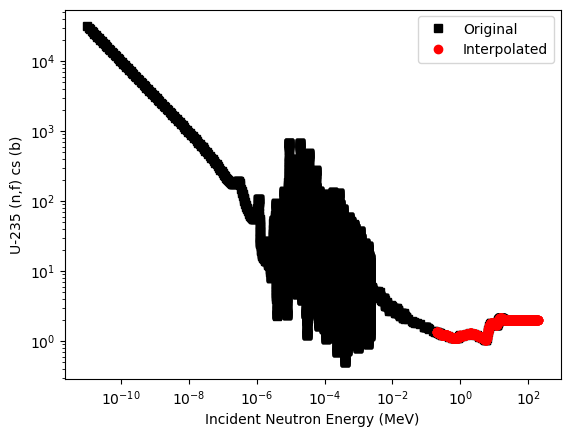

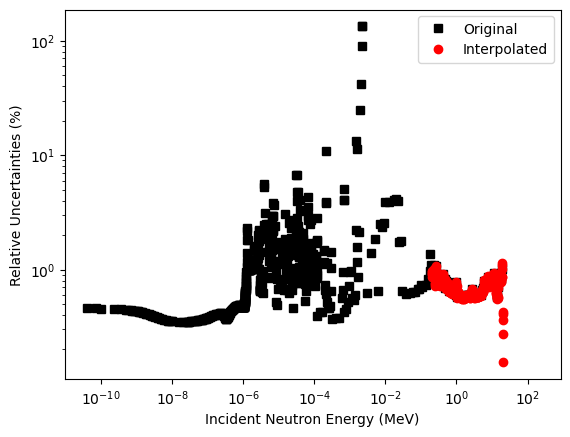

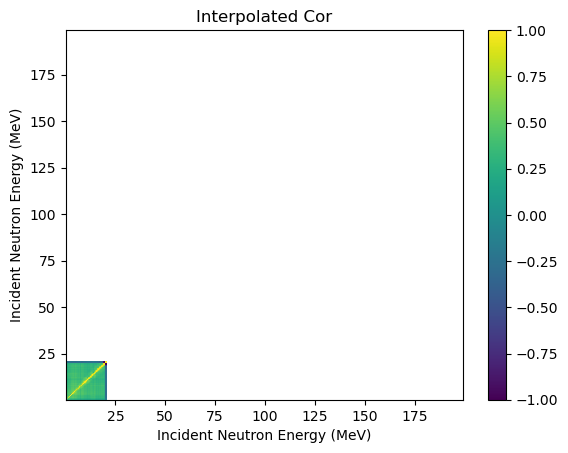

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS8002_Tovesson/DS8002.xml
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS8002_Tovesson/DS8002EUCLID.json
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS8002_Tovesson/DS8002ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS8002_Tovesson/Partial_Unc.dat



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


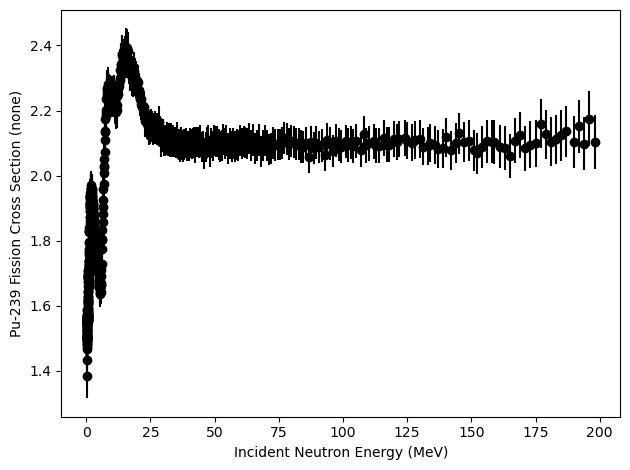

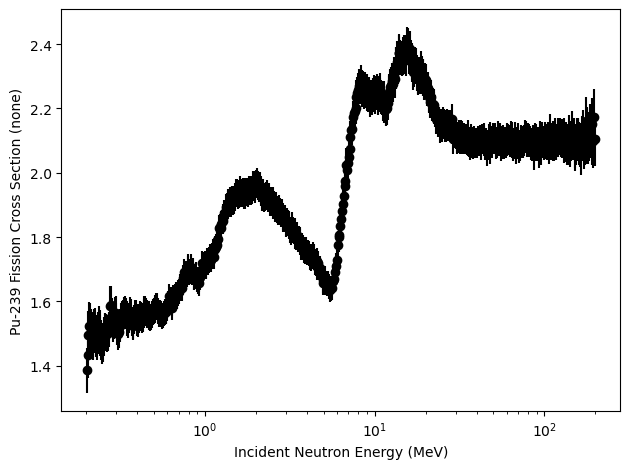

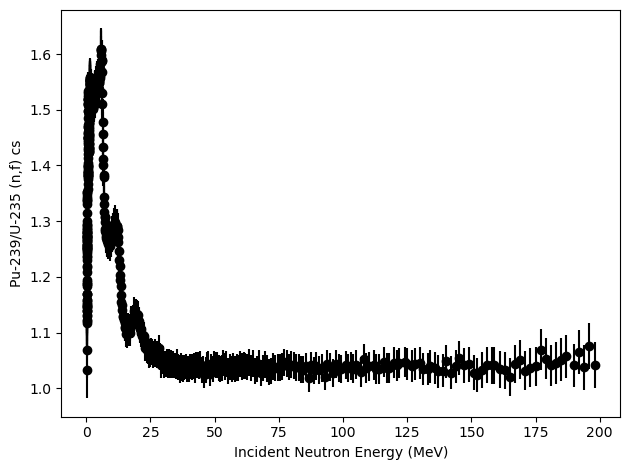

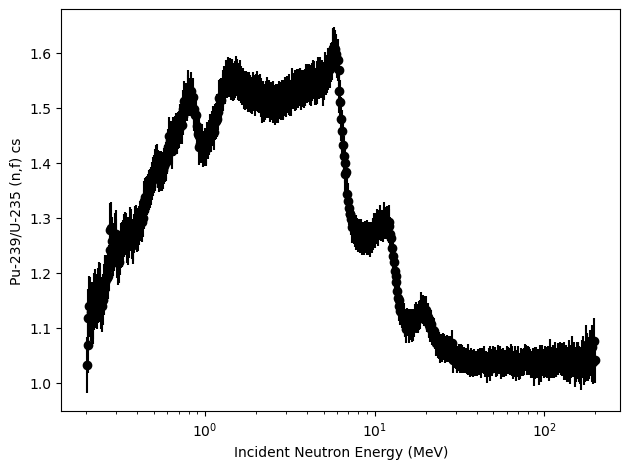

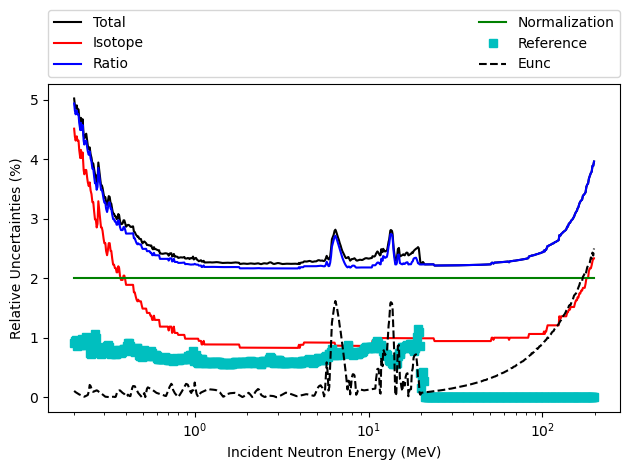

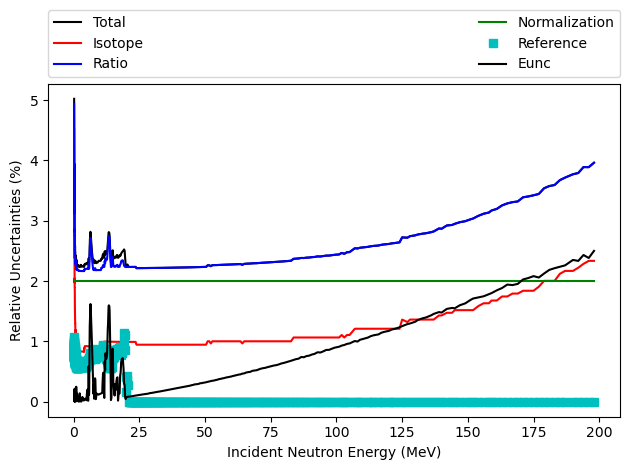

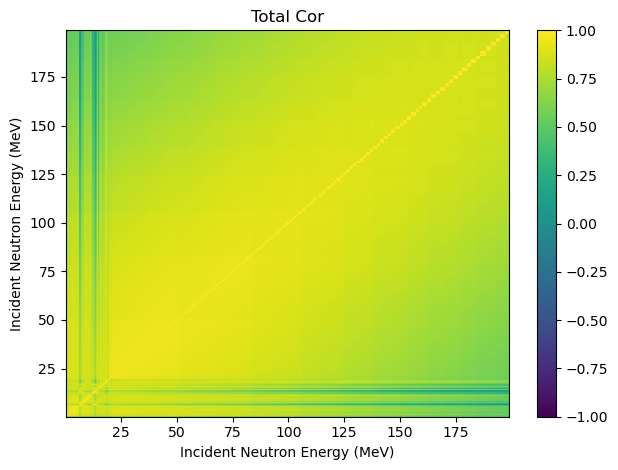

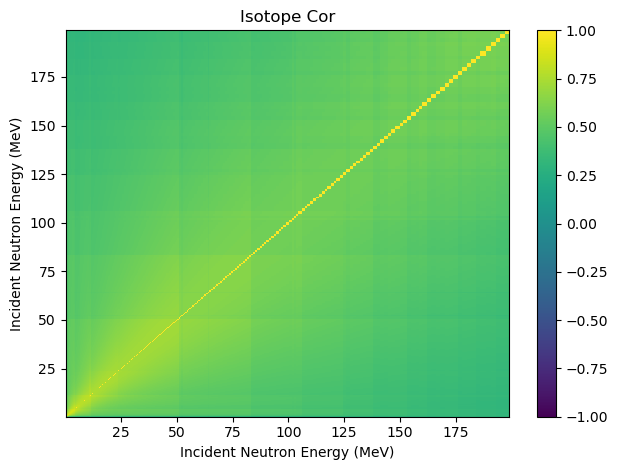

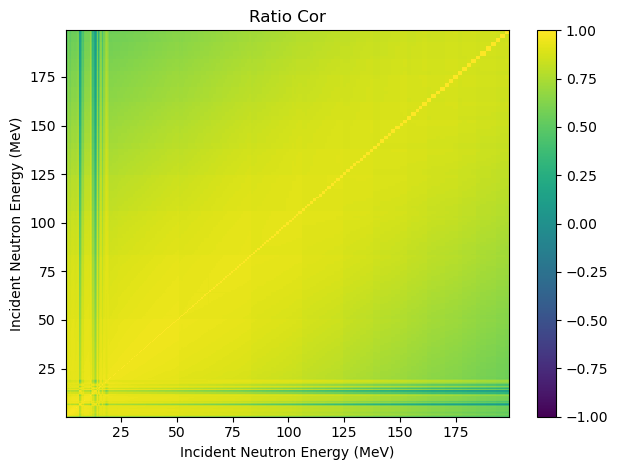

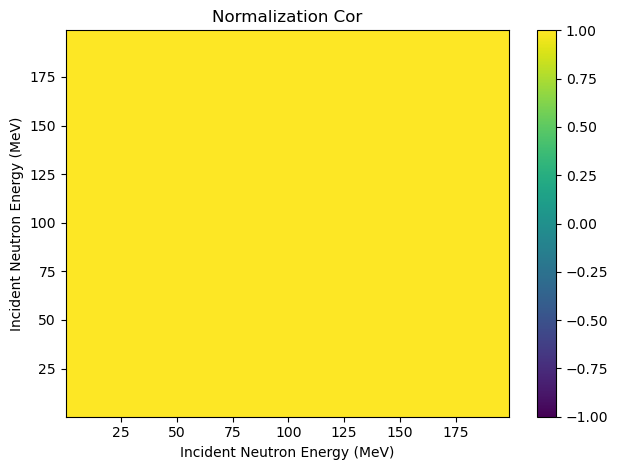

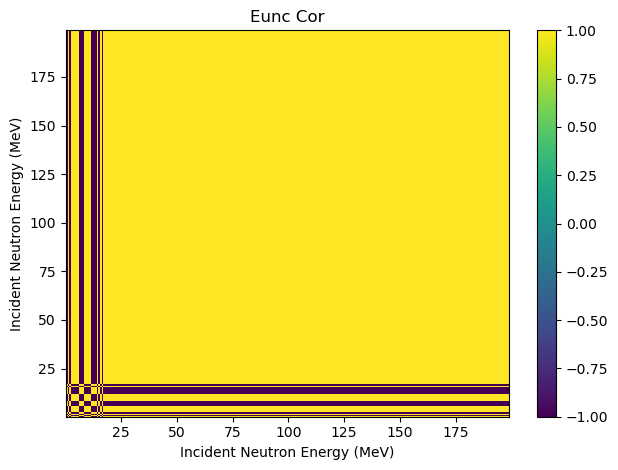

In [17]:
Documentation = "EXFOR No. = 14271.003; in GMA the data have the data set numbers 8002; Journal article = \
	F. Tovesson et al., NSE 165, 224 (2010) (Pu-9); F. Tovesson et al., NSE 159, 94 (2008;) \
	All data are taken from EXFOR.  The statistical unc. is explicitly given in EXFOR. The U-235 \
	background reduction uncertainty is explicitly given in  EXFOR. I assume it to be Gaussian \
	correlated.The Pu-239 background reduction uncertainty is explicitly given in EXFOR. I \
	assume it to be Gaussian correlated. The normalization uncertainty was defined by comparison \
	to the thermal cross section ratio and therefore completely different than from any other \
	measurement. It was not included in the GMA uncertainty estimate. It is fully correlated. All \
	data points in that measurement are from the WNR measurement and therefore, only time \
	resolution and TOF length uncertainties apply for this part of the measurement. The \
 	uncertainty on the residual detector efficiency uncertainty is given in the Np-237 \
	paper and accounts for different thresholds for Pu-9 and U-235. I assume a full correlation. \
	The deadtime uncertainty is given in the Np-237 paper. I assume a full correlation. \
	No impurity uncertainty is given. I assume the value provided by Kyle Schmitt calculated \
	for that level of contamination. I assume full correlation. No angular distribution \
	uncertainty is provided. I assume 0.1%. I assume it to be Gaussian correlated following \
	the template. Given the high Einc, this could actually be a larger uncertainty. No \
 	attenuation uncertainty was given, so I assume the uncertainty by the template. Fredrik \
 	mentioned that he reduced the attenuation effect in his paper by careful design. So, a small \
	uncertainty should be ok. I assume it to be Gaussian correlated. The multiple scattering \
 	uncertainty is reduced in ratio measurement according to the template. Here, I assume \
 	something which seems reasonable until Fredrik gets back to me. All in all well documented on \
	unc. but only statunc and background unc. made it into GMA. So, my estimate will be significantly \
	higher.  Fredrik thinks my assumption are reasonable (communication by e-mail Feb. 2018)."

general_info = {'name': 'DS8002', 'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS8002.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', 'unc': TOFlenght_unc, 'unc_unit': 'm'}, \
            'trsl' : {'value': trsl, 'unit': 'ns'},\
            'identifier_iso_deriv1' : 'ENDF/B-VII.1'
            }

norm_unc = {'value': normalization, 'unit':'%'}

reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VII.1'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc,\
           'values':array([statunc,backgrdU5,backgrdPu9,detectorunc,deadtime,\
                           impurity,angdistribution,attenuation,multscatt]).transpose(),\
           'units':['%'],\
           'type':['Diagonal','Gaussian','Gaussian','Positive_fully','Positive_fully',\
                   'Positive_fully','Gaussian','Gaussian','Gaussian'],\
           'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "none" }

test_absolute_nfcs = Cnf.nfcs_cleanratioabsolute(general_info,data,unc_iso,reference,features)

In [21]:
GMAnewnumber='8002'
year = '2010'
authors = 'F.Tovesson,T.S.Hill'
journal = 'J,NSE,165,224(2010)'
uncertainty_descriptor = ['CS and UNC for RATIO: original file, no averaging','UNCERTAINTIES','3 Statistical Unc.',\
                          '4 U-235 background unc.','5 Pu-239 background unc.',\
                          '6 Residual Detector Efficiency Unc.','7 Deadtime Unc.', '8 Impurity Unc.', \
                          '9 Angular distribution unc.','10 Attenuation Unc.', '11 Multiple Scattering Uncertainty',\
                         'changes DN 110218: (a) changed to shape data as measured relative to thermal point',\
                         'added: detector efficiency, deadtime, impurity, angular distribution, attenuation',\
                          'and multiple scattering unc.; changes were discussed with F. Tovesson']
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0:3,:] = zeros([3,3],dtype=float)
abc_components[5:8,:] = [0.99,0.01,0.5] # LERC for shape, variational
Eunc = zeros(dim,dtype=float)
Enrsl = zeros(dim,dtype=float)
uncertainties = zeros([dim,10],dtype=float)
uncertainties[:,:9] = array([statunc,backgrdU5,backgrdPu9,detectorunc,deadtime,\
                             impurity,angdistribution,attenuation,multscatt]).transpose()

controlnumber = [0,0,9,1,1,1,1,1,1,1,1]
normalizationunc = zeros(10,dtype = float)

abs_shape = 'shape'

In [23]:
import WriteGMAOutput as WGMA

In [25]:
print(WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc))

/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_DS8002_Tovesson/DS8002.CRD
